# 6CS012 - Artificial Intelligence and Machine Learning
## Tutorial 7: Representation Learning and Autoencoder


In [1]:
# Install / verify libraries
!pip install tensorflow numpy matplotlib pillow scikit-learn -q
print("Libraries ready.")

Libraries ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request, zipfile, glob

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from PIL import Image

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


---
Step 1: Load, pre - process and add a Noise to the Dataset:
---

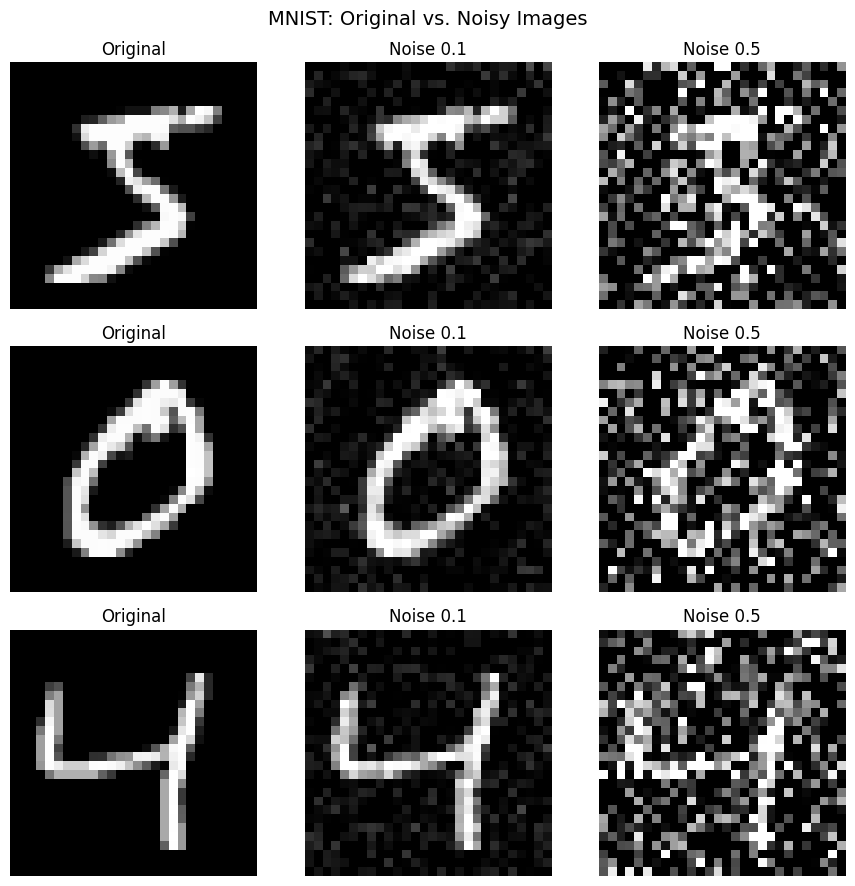

In [17]:

n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original");  plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1"); plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5"); plt.axis('off')

plt.suptitle("MNIST: Original vs. Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

### Step 2 — Build the Convolutional Denoising Autoencoder

In [9]:
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [11]:
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [12]:
def build_autoencoder(input_shape=(28, 28, 1)):
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# ── Build and print summary ───────────────────────────────────────────────────
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3 — Train the Autoencoder

In [13]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,        # INPUT: noisy  |  TARGET: clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.1530 - val_loss: 0.1135
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1096 - val_loss: 0.1057
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1049 - val_loss: 0.1022
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1019 - val_loss: 0.1001
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1002 - val_loss: 0.0986
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0990 - val_loss: 0.0977
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0981 - val_loss: 0.0970
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0974 - val_loss: 0.0963
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0968 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0963 - val_loss: 0.0955


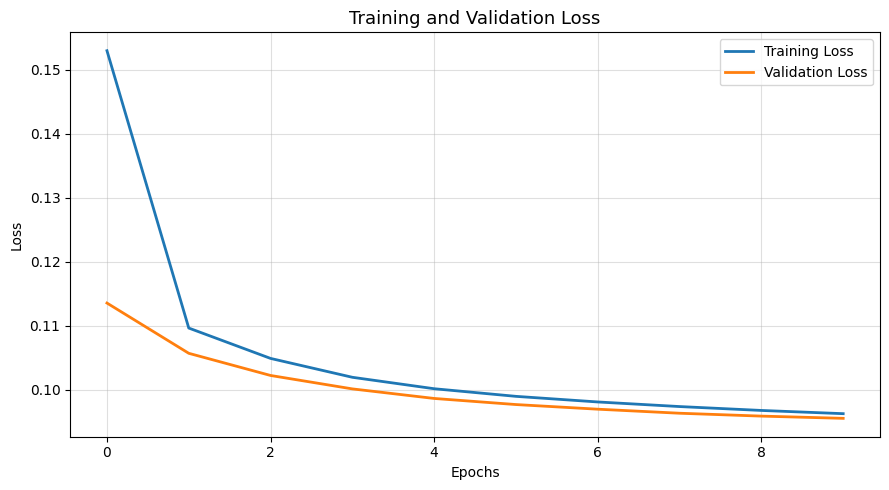

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Step 4 — Evaluate the Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


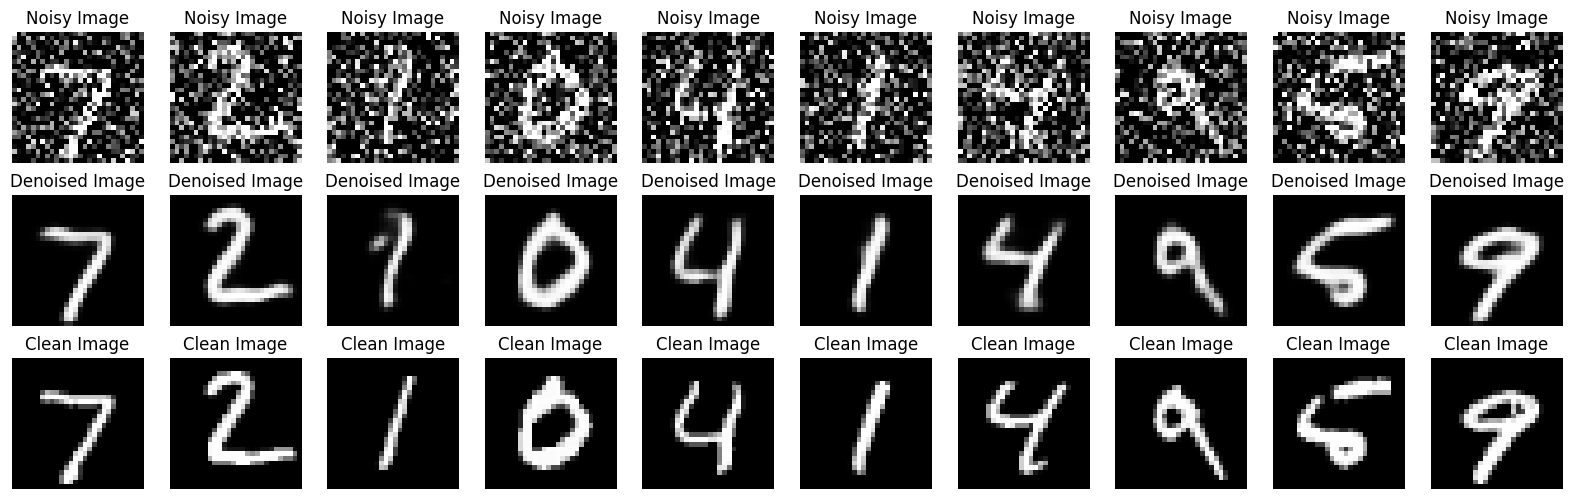

In [18]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.show()

# Display the first 10 images
plot_images(x_test_noisy, denoised_images, x_test, n=10)

---
## Part 2 — Exercise: Denoising Autoencoder on Devanagari Handwritten Digit Dataset
---


1. Dataset Preparation & Preprocessing

In [20]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI 6th sem/Copy of devnagari digit.zip"
extract_path = "/content/devnagari"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

# Check folders
os.listdir(extract_path)

Extraction Done!


['DevanagariHandwrittenDigitDataset']

STEP 2: Load & Preprocess Dataset

In [24]:
import glob
import numpy as np
from PIL import Image

IMG_SIZE = 32
MAX_IMGS = 10000

DATA_DIR = extract_path  # use extracted folder

# Find all images
img_paths = glob.glob(os.path.join(DATA_DIR, '**', '*.png'), recursive=True)

print("Total images found:", len(img_paths))  # must NOT be 0

images = []

for path in img_paths[:MAX_IMGS]:
    try:
        img = Image.open(path).convert('L')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        images.append(np.array(img, dtype='float32'))
    except:
        continue

# Convert to numpy
X = np.array(images)

# Normalize
X = X / 255.0

# Add channel dimension
X = X[..., np.newaxis]

print("Dataset shape:", X.shape)

Total images found: 20000
Dataset shape: (10000, 32, 32, 1)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.15, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (8500, 32, 32, 1)
Val: (1500, 32, 32, 1)


In [26]:
NOISE = 0.4

X_train_noisy = np.clip(X_train + NOISE * np.random.normal(0., 1., X_train.shape), 0., 1.)
X_val_noisy   = np.clip(X_val   + NOISE * np.random.normal(0., 1., X_val.shape),   0., 1.)

In [27]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)

# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(1e-3), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,425 (2.96 MB)

 Trainable params: 775,425 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

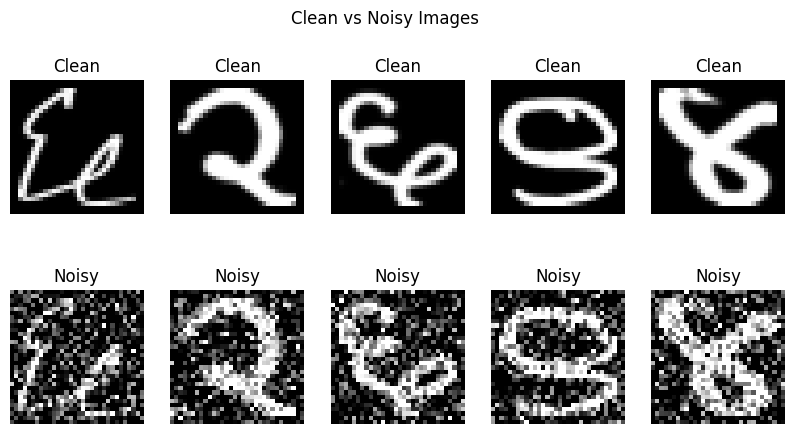

In [32]:
import matplotlib.pyplot as plt

n = 5  # number of samples

plt.figure(figsize=(10,5))

for i in range(n):
    # Clean image
    plt.subplot(2, n, i+1)
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Noisy image
    plt.subplot(2, n, i+1+n)
    plt.imshow(X_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Clean vs Noisy Images")
plt.show()

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_noisy, X_val),
    callbacks=[early_stop]
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.3721 - val_loss: 0.2405
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2068 - val_loss: 0.1861
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1763 - val_loss: 0.1724
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1644 - val_loss: 0.1661
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1577 - val_loss: 0.1564
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1523 - val_loss: 0.1522
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1485 - val_loss: 0.1494
Epoch 8/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1453 - val_loss: 0.1470
Epoch 9/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1427 - val_loss: 0.1460
Epoch 10/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1409 - val_loss: 0.1449
Epoch 11/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1398 - val_loss: 0.1438
Epoch 12/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/st

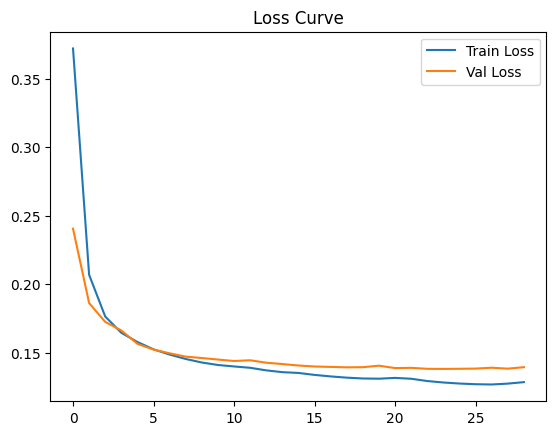

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


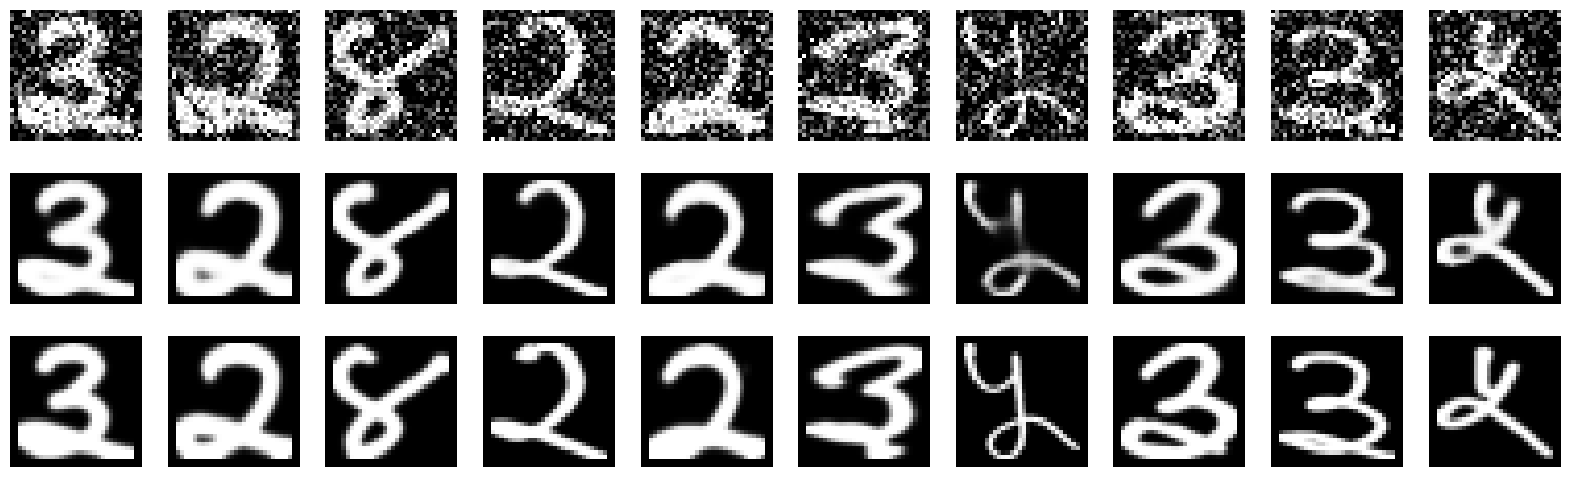

In [30]:
denoised = autoencoder.predict(X_val_noisy[:10])

n = 10
plt.figure(figsize=(20,6))

for i in range(n):
    # Noisy
    plt.subplot(3,n,i+1)
    plt.imshow(X_val_noisy[i].reshape(IMG_SIZE,IMG_SIZE), cmap='gray')
    plt.axis('off')

    # Denoised
    plt.subplot(3,n,i+1+n)
    plt.imshow(denoised[i].reshape(IMG_SIZE,IMG_SIZE), cmap='gray')
    plt.axis('off')

    # Clean
    plt.subplot(3,n,i+1+2*n)
    plt.imshow(X_val[i].reshape(IMG_SIZE,IMG_SIZE), cmap='gray')
    plt.axis('off')

plt.show()

In [31]:
print(len(img_paths))

20000
